#**Fusão Multimodal**
Neste Notebook são apresentados operadores de fusão prévia de características aplicados a características de médio nível semântico de diferentes modalidades.

Ao fazer a fusão no médio nível, em vez de fazer no baixo nível, consegue-se explorar melhor a semântica latente contida nos dados. O resultado esperado é uma melhora de eficácia quando as representações fundidas são utilizadas em tarefas computacionais (como classificação, recomendação, etc.).

Diferente das representações obtidas no processo de **Enriquecimento Semântico**, que são representações unimodias (ou somente visuais ou somente aurais), aqui a representação obitada é um histograma com informações de mais de uma modalidade - **multimodal**.


#Preparação do ambiente do Notebook





**Instalando Dependências**

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt


**Acesso ao Drive - para armazenamento de Arquivos**

O *pathname* precisa ser personalizado com o Drive do usuário deste Notebook. Atenção: alguns *pathnames* podem estar em Inglês enquanto outros em Português - verifique o seu caso. Crie um pasta no **seu** Drive onde os arquivos serão armazenados. 

In [2]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


#<h1>Operadores de Fusão Prévia Aplicados em Representações de Médio Nível Semântico</h1>

Os operadores de fusão são práticos, simples de implementar e computacionalmente baratos. Beserra et al. (2020) (veja referência abaixo) demonstram que aplicados em médio nível semântico possuem eficácia equiparável a métodos recentes de fusão mais complexos.

Antonio A. R. Beserra, Rodrigo M. Kishi, and Rudinei Goularte. 2020. Evaluating Early Fusion Operators at Mid-Level Feature Space. In Proceedings of the Brazilian Symposium on Multimedia and the Web (WebMedia '20). Association for Computing Machinery, New York, NY, USA, 113–120. DOI:https://doi.org/10.1145/3428658.3431079

In [3]:
#Operador de Fusão Soma
def sumOperator (visual, aural):
    sumFused = []

    for i in range(len(visual)):
      a = aural[i]
      v = visual[i]
      sumFused.append(aural[i]+visual[i])

    return (sumFused)

#Operador de Fusão Máximo
def maxOperator(visual, aural):
    maxFused = visual.copy()
    qtdTomadas = len(visual)
    tamHist = len(visual[0])

    for tomada in range(qtdTomadas):
        for i in range (tamHist):
            if (visual[tomada][i] < aural[tomada][i]):
                maxFused[tomada][i] = aural[tomada][i]
    return (maxFused)

#Operador de Fusão Média
def avgOperator(visual, aural):
    avgFused = []

    for i in range(len(visual)):
      avg = (aural[i]+visual[i])/2
      avgFused.append(avg)
    return (avgFused)

#Script para a geração de histograma multimodal
Será gerado um  histograma para cada vídeo da
base, sendo que os histogramas serão armazenados em uma lista ("multiModalHistogram") e a lista será salva em arquivo. Cada histograma constitui uma **representação multimodal** (visual e aural nesse caso) de um vídeo, fundidas por meio de um operador específico.

O arquivo poderá ser usado posteriormente para recuperar a lista e usar os histogramas que representam os vídeos em tarefas ou aplicações computacionais.

Multimodal:  [  0.    0.   29.    0.   13.    0.    0.   15.    0.5   0.  178.5   2.
   0.    9.    0.    0.    0.    5.5   0.    1.5  24.    0.5   0.    0.
   0.   60.5   0.5   0.    0.    0.    0.    0.    1.    0.    0.5   0.
   0.5   0.    7.5   0.    0.    2.   86.5   1.    0.    0.    0.    6.
   0.    0.    0.    0.    0.    2.    0.    0.    0.    0.    0.    3.5
  71.5   0.    0.    0.   38.5   0.    0.    1.    0.    0.    0.    1.
   0.5  31.5   1.   37.5   3.    0.    2.    0.    0.    0.    3.   11.5
   0.    0.    0.    0.5   0.5   0.    0.   13.    0.5   0.    0.    0.5
   0.    0.    0.    0. ]


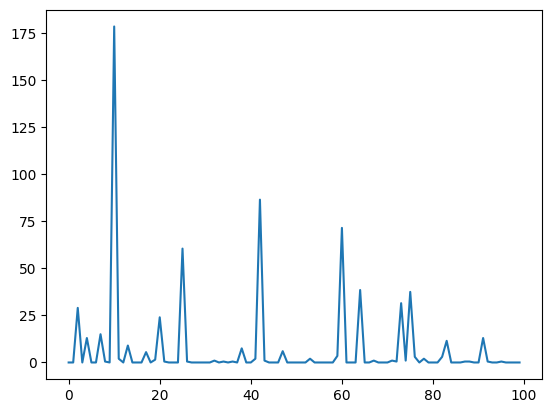

In [16]:
visualHistogram = []

#Recuperando representação monomodal visual previamente computada e salva em arquivo
#O número ao fim do nome do arquivo indica a dimesão de cada histograma, que vem
#do tamanho do dicionário usado para gerar a representação monomodal.
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Visuais/visual_histogram_100_cosine_bbc_11.arq', 'rb') as arq1:

    visualHistogram = pickle.load(arq1)

#Idem para a reprensentação monomodal aural.
auralHistogram = []
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Aurais/aural_histogram_100_cosine_bbc_11.arq', 'rb') as arq2:
    auralHistogram = pickle.load(arq2)

#Aplicando o operador de fusão.#
multiModalHistogram = avgOperator(visualHistogram, auralHistogram)

#Salvado  os histogramas em arquivo
#A pasta "histogramas" deve existir dentro de "MBA_Curso14_Dados"
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Multimodais_AVG/mm_avg_histogram_bbc_11_100_cosine.arq', 'wb') as arq_mm:
    pickle.dump(multiModalHistogram, arq_mm)

#Imprimindo o histograma multimodal do 1o vídeo da base
print("Multimodal: ", multiModalHistogram[0])

plt.plot(multiModalHistogram[0])
plt.show()


In [17]:
print(visualHistogram[0])
print(auralHistogram[0])

[0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 2. 0. 0. 0. 0. 0. 3. 0. 1. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 1. 0. 0. 4. 1. 2. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 4. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 2. 0. 0. 0. 0. 0. 0. 0. 2. 1. 0. 0. 0. 0. 1. 0. 0. 6. 0. 0. 0. 1.
 0. 0. 0. 0.]
[  0.   0.  58.   0.  26.   0.   0.  30.   0.   0. 357.   4.   0.  16.
   0.   0.   0.  11.   0.   0.  48.   0.   0.   0.   0. 121.   1.   0.
   0.   0.   0.   0.   1.   0.   1.   0.   1.   0.  14.   0.   0.   0.
 172.   0.   0.   0.   0.  12.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   7. 143.   0.   0.   0.  76.   0.   0.   0.   0.   0.
   0.   2.   1.  63.   0.  75.   6.   0.   4.   0.   0.   0.   4.  22.
   0.   0.   0.   1.   0.   0.   0.  20.   1.   0.   0.   0.   0.   0.
   0.   0.]
